# Inpatient Glucose Patterns and Length of Stay: a Machine-Learning Learning Project

**Data:** MIMIC-IV Clinical Database *Demo* (v2.2), the small open-access practice version.

**Status:** a learning project. It is **not** a clinical study and **not** a validated prediction tool.

## The question

Among hospital stays with a recorded diabetes diagnosis, can the **blood glucose readings from the first 48 hours** help us guess which stays will turn out to be **long** (more than 7 days)?

## The idea in plain words

- A hospital stay is like a school day. Glucose readings are like checking the temperature of the classroom again and again.
- We only look at the **first two days**. That is fair, because on day 2 nobody knows yet how long the stay will be.
- Then we ask a computer to practise guessing: *"Will this stay be long?"*
- We also test the computer on stays it has **never seen**, so it cannot cheat.

## Important

The demo data has only about 100 patients, so the results will be **wobbly**. The goal is to learn a correct way of doing the work. Finding something new is not the goal.

## Step 0. Get our tools ready

Python tools are like a toy box. Each one does one job:

- `pandas` = tables (like Excel, but with code)
- `numpy` = maths
- `matplotlib` = pictures
- `scikit-learn` = the machine-learning tools

The **settings** below are the rules of our project. We write them in one place so anyone can see them. We choose them **before** we look at any results, so we are not tempted to pick the ones that look best.

In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupKFold

# ---------- Our project rules (decided BEFORE looking at results) ----------
WINDOW_HOURS = 48       # we only use glucose readings from the first 48 hours
MIN_READINGS = 3        # a stay needs at least this many readings in that window
LONG_STAY_DAYS = 7      # "long stay" means longer than 7 days
LOW_MGDL = 70           # below this = low glucose (hypoglycaemia)
HIGH_MGDL = 180         # above this = high glucose (hyperglycaemia)
SEED = 42               # makes random choices repeatable

Path("figures").mkdir(exist_ok=True)
print("Tools ready.")

Tools ready.


## Step 1. Get the data

The MIMIC-IV **Demo** is open to everyone, so no special approval is needed. (The full MIMIC-IV needs approval, but we are not using it here.)

We only download the **5 files** we need. Each file is a table:

| File | What is inside |
|---|---|
| `admissions` | one row per hospital stay (arrival time, leaving time) |
| `patients` | age and sex |
| `diagnoses_icd` | the diagnosis codes for each stay |
| `labevents` | the lab results, including glucose |
| `d_labitems` | the dictionary that says what each lab code means |

The files are saved in a folder called `data/`. That folder is **not uploaded** to GitHub (see `.gitignore`).

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

BASE_URL = "https://physionet.org/files/mimic-iv-demo/2.2/hosp/"
NEEDED_FILES = [
    "admissions.csv.gz",
    "patients.csv.gz",
    "diagnoses_icd.csv.gz",
    "labevents.csv.gz",
    "d_labitems.csv.gz",
]

for name in NEEDED_FILES:
    path = DATA_DIR / name
    if path.exists():
        print("Already have:", name)
        continue
    print("Downloading:", name)
    request = urllib.request.Request(BASE_URL + name, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request) as response, open(path, "wb") as out_file:
        out_file.write(response.read())

print("All files are in the data/ folder.")

Downloading: admissions.csv.gz
Downloading: patients.csv.gz
Downloading: diagnoses_icd.csv.gz
Downloading: labevents.csv.gz
Downloading: d_labitems.csv.gz
All files are in the data/ folder.


In [3]:
admissions = pd.read_csv(DATA_DIR / "admissions.csv.gz", parse_dates=["admittime", "dischtime"])
patients = pd.read_csv(DATA_DIR / "patients.csv.gz")
diagnoses = pd.read_csv(DATA_DIR / "diagnoses_icd.csv.gz")
lab_items = pd.read_csv(DATA_DIR / "d_labitems.csv.gz")
labs = pd.read_csv(
    DATA_DIR / "labevents.csv.gz",
    usecols=["hadm_id", "itemid", "charttime", "valuenum", "valueuom"],
    parse_dates=["charttime"],
)

print("Hospital stays (admissions):", admissions["hadm_id"].nunique())
print("Patients:", patients["subject_id"].nunique())
print("Lab result rows:", len(labs))

Hospital stays (admissions): 275
Patients: 100
Lab result rows: 107727


**Words to know**

- `subject_id` = the **patient** (one person, can have several stays)
- `hadm_id` = one **hospital stay**

One patient can come to hospital more than once. This matters later: two stays from the same person are *not* independent, so we keep them together when we test our model.

## Step 2. Find the stays with diabetes

Doctors write diagnoses as **codes** (ICD codes). Hospitals used two code books over time, so we look for both:

- ICD-9: codes starting with `250`
- ICD-10: codes starting with `E08`, `E09`, `E10`, `E11` or `E13`

We keep a **cohort flow list** as we go. It records how many stays are left after each step, so nothing disappears without a trace.

In [4]:
diagnoses["icd_code"] = (
    diagnoses["icd_code"].astype(str).str.upper().str.replace(".", "", regex=False).str.strip()
)
diagnoses["icd_version"] = pd.to_numeric(diagnoses["icd_version"], errors="coerce")

is_icd9_diabetes = (
    (diagnoses["icd_version"] == 9)
    & diagnoses["icd_code"].str.startswith("250")
)
# Include E11 (type 2 diabetes), along with other diabetes code families.
is_icd10_diabetes = (
    (diagnoses["icd_version"] == 10)
    & diagnoses["icd_code"].str.startswith(("E08", "E09", "E10", "E11", "E13"))
)

diabetes_hadm_ids = (
    diagnoses.loc[is_icd9_diabetes | is_icd10_diabetes, "hadm_id"]
    .dropna()
    .astype(int)
    .unique()
)

cohort_flow = []
cohort_flow.append(("All hospital stays in the demo", admissions["hadm_id"].nunique()))
cohort_flow.append(("Stays with a diabetes diagnosis code", len(diabetes_hadm_ids)))

print("Stays with a diabetes diagnosis code:", len(diabetes_hadm_ids))


Stays with a diabetes diagnosis code: 112


## Step 3. Find the blood glucose readings

The lab dictionary tells us which lab codes mean **"Glucose in Blood"**. There can be more than one code (for example, one machine type versus another), so we print them and look.

In [5]:
glucose_items = lab_items[(lab_items["label"] == "Glucose") & (lab_items["fluid"] == "Blood")]
print(glucose_items.to_string(index=False))

 itemid   label fluid  category
  50809 Glucose Blood Blood Gas
  50931 Glucose Blood Chemistry
  52569 Glucose Blood Chemistry


Now we take only the glucose readings from our diabetes stays, and we **clean** them:

1. Remove rows with a missing stay, time or value.
2. Check the **unit**. We only keep readings in `mg/dL`, so we never mix units by mistake.
3. Remove impossible values (below 10 or above 1500 mg/dL). This is only a basic "typo catcher", not a medical rule.

Then we calculate **hours since arrival** for every reading, so we can look at the first 48 hours only.

In [6]:
g = labs[labs["itemid"].isin(glucose_items["itemid"])].copy()
g = g.dropna(subset=["hadm_id", "charttime", "valuenum"])
g["hadm_id"] = g["hadm_id"].astype(int)
g = g[g["hadm_id"].isin(diabetes_hadm_ids)]

print("Units found among the readings:")
print(g["valueuom"].value_counts(dropna=False).to_string())

n_before = len(g)
g = g[g["valueuom"] == "mg/dL"]
print("Rows dropped because the unit was not mg/dL:", n_before - len(g))

n_before = len(g)
g = g[g["valuenum"].between(10, 1500)]
print("Rows dropped as impossible values:", n_before - len(g))

# add arrival and leaving times, then work out hours since arrival
g = g.merge(admissions[["hadm_id", "subject_id", "admittime", "dischtime"]], on="hadm_id", how="left")
g["hours_since_admit"] = (g["charttime"] - g["admittime"]).dt.total_seconds() / 3600

# simple yes/no labels for each reading
g["is_low"] = g["valuenum"] < LOW_MGDL
g["is_high"] = g["valuenum"] > HIGH_MGDL
g["is_in_range"] = g["valuenum"].between(LOW_MGDL, HIGH_MGDL)

cohort_flow.append(("Stays with at least 1 valid glucose reading", g["hadm_id"].nunique()))
print("Valid glucose readings kept:", len(g))

Units found among the readings:
valueuom
mg/dL    1060
Rows dropped because the unit was not mg/dL: 0
Rows dropped as impossible values: 0
Valid glucose readings kept: 1060


## Step 4. Use only the first 48 hours (this is the key fairness rule)

Why? Imagine guessing the length of a stay **after** it is over. Long stays have more readings and more chances to have a low or high value, so the "clues" would secretly contain the answer. That is called **leakage**, and it makes a model look clever when it is not.

So we only use what a doctor could know **at 48 hours**:

- only readings from hour 0 to hour 48;
- only stays that are **still going** at hour 48 (a stay that ended on day 1 has no "guess" to make);
- only stays with at least `MIN_READINGS` readings in that window.

In [7]:
admissions["los_days"] = (admissions["dischtime"] - admissions["admittime"]).dt.total_seconds() / 86400

still_in_hospital = set(admissions.loc[admissions["los_days"] * 24 >= WINDOW_HOURS, "hadm_id"])
had_readings = set(g["hadm_id"])

g_window = g[
    (g["hours_since_admit"] >= 0)
    & (g["hours_since_admit"] <= WINDOW_HOURS)
    & (g["hadm_id"].isin(still_in_hospital))
].copy()

readings_per_stay = g_window.groupby("hadm_id").size()
enough_readings = set(readings_per_stay[readings_per_stay >= MIN_READINGS].index)

cohort_flow.append((f"...and still in hospital at {WINDOW_HOURS} hours", len(had_readings & still_in_hospital)))
cohort_flow.append((f"...and at least {MIN_READINGS} readings in the first {WINDOW_HOURS} hours", len(enough_readings)))

g_window = g_window[g_window["hadm_id"].isin(enough_readings)]

flow_table = pd.DataFrame(cohort_flow, columns=["Step", "Hospital stays left"])
print(flow_table.to_string(index=False))

                                            Step  Hospital stays left
                  All hospital stays in the demo                  275
            Stays with a diabetes diagnosis code                  112
     Stays with at least 1 valid glucose reading                  103
            ...and still in hospital at 48 hours                   89
...and at least 3 readings in the first 48 hours                   48


Look at the last row of the table. That is **how many stays we really have** for machine learning. If it is very small, that is an honest finding about the demo data. Do not hide it.

## Step 5. Turn many readings into a few clues ("features")

A stay has many readings, but a model needs **one row per stay**. So we summarise each stay with simple numbers. Each number is a **feature** (a clue):

| Clue | Plain meaning |
|---|---|
| `n_readings` | how many times glucose was checked |
| `mean_glucose` | the average |
| `sd_glucose` | how much the values jump around |
| `cv_glucose` | the jumpiness compared with the average (SD divided by mean, as a %) |
| `min_glucose`, `max_glucose` | the lowest and highest value |
| `pct_low` | % of readings below 70 |
| `pct_high` | % of readings above 180 |
| `pct_in_range` | % of readings from 70 to 180 |
| `anchor_age`, `is_female` | age and sex |

The **answer** we want to guess is `long_stay`: **1** if the stay lasted more than 7 days, **0** if not.

In [8]:
if g_window.empty:
    raise ValueError("No admissions meet the 48-hour and minimum-reading rules. Stop here; modelling is not possible.")

features = (
    g_window.groupby("hadm_id")
    .agg(
        n_readings=("valuenum", "size"),
        mean_glucose=("valuenum", "mean"),
        sd_glucose=("valuenum", "std"),
        min_glucose=("valuenum", "min"),
        max_glucose=("valuenum", "max"),
        pct_low=("is_low", "mean"),
        pct_high=("is_high", "mean"),
        pct_in_range=("is_in_range", "mean"),
    )
    .reset_index()
)

features["cv_glucose"] = features["sd_glucose"] / features["mean_glucose"] * 100
for col in ["pct_low", "pct_high", "pct_in_range"]:
    features[col] = features[col] * 100

# add patient id, stay length, age and sex
features = features.merge(admissions[["hadm_id", "subject_id", "los_days"]], on="hadm_id", how="left")
features = features.merge(patients[["subject_id", "gender", "anchor_age"]], on="subject_id", how="left")
features["is_female"] = (features["gender"] == "F").astype(int)

# the answer we want to guess
features["long_stay"] = (features["los_days"] > LONG_STAY_DAYS).astype(int)

cohort = features.copy()

print("Stays in our final table:", len(cohort))
print("Different patients:", cohort["subject_id"].nunique())
print("Long stays (1):", int(cohort["long_stay"].sum()), "| Not long (0):", int((cohort["long_stay"] == 0).sum()))
cohort.head()

Stays in our final table: 48
Different patients: 27
Long stays (1): 27 | Not long (0): 21


,hadm_id,n_readings,mean_glucose,sd_glucose,min_glucose,max_glucose,pct_low,pct_high,pct_in_range,cv_glucose,subject_id,los_days,gender,anchor_age,is_female,long_stay
0,20192635,3,262.666667,85.277977,209.0,361.0,0.000000,100.000000,0.000000,32.466235,10037928,3.170139,F,78,1,0
1,20755971,3,113.666667,78.678671,44.0,199.0,33.333333,33.333333,33.333333,69.218772,10038081,14.138889,F,63,1,1
2,20790339,3,191.000000,89.269256,98.0,276.0,0.000000,66.666667,33.333333,46.737830,10015860,2.521528,M,53,0,0
3,20973395,4,122.000000,16.573071,104.0,138.0,0.000000,0.000000,100.000000,13.584484,10016810,5.600000,F,66,1,0
4,21457723,6,118.833333,31.051033,101.0,181.0,0.000000,16.666667,83.333333,26.129902,10019003,7.965972,F,65,1,1


In [9]:
summary_cols = ["n_readings", "mean_glucose", "sd_glucose", "cv_glucose",
                "pct_low", "pct_high", "pct_in_range", "anchor_age", "los_days"]
cohort[summary_cols].describe().round(1)

,n_readings,mean_glucose,sd_glucose,cv_glucose,pct_low,pct_high,pct_in_range,anchor_age,los_days
count,48.0,48.0,48.0,48.0,48.0,48.0,48.0,48.0,48.0
mean,4.8,185.8,56.5,30.2,1.4,42.0,56.6,64.4,9.8
std,2.3,69.1,37.2,17.8,6.7,33.5,33.8,13.3,7.5
min,3.0,93.3,7.0,4.2,0.0,0.0,0.0,29.0,2.5
25%,3.0,133.4,29.0,16.9,0.0,16.1,27.7,58.0,5.0
50%,4.0,171.0,47.2,26.9,0.0,33.3,66.7,64.0,7.9
75%,5.2,215.6,77.2,40.0,0.0,72.3,83.9,71.8,13.2
max,13.0,373.8,152.7,88.8,33.3,100.0,100.0,91.0,44.9


## Step 6. Look before you model

Always **draw pictures first**. A model can hide mistakes; a picture usually shows them.

- **Picture 1:** all glucose readings in the first 48 hours. The dashed lines mark 70 and 180.
- **Picture 2:** a few clues, split by long stay versus not long stay.

These are only **descriptions**. They do not show that glucose *causes* a long stay. A very sick patient may have both high glucose and a long stay.

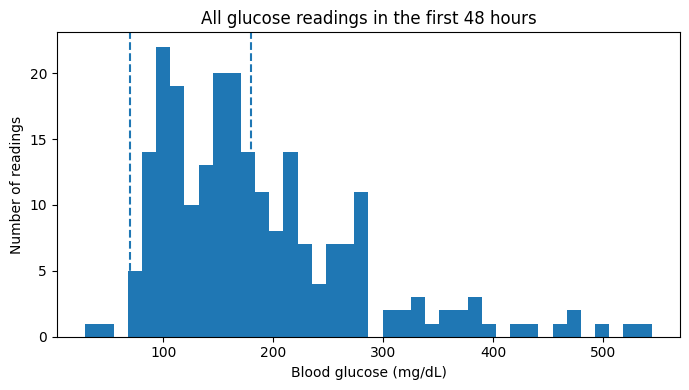

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(g_window["valuenum"], bins=40)
ax.axvline(LOW_MGDL, linestyle="--")
ax.axvline(HIGH_MGDL, linestyle="--")
ax.set_xlabel("Blood glucose (mg/dL)")
ax.set_ylabel("Number of readings")
ax.set_title(f"All glucose readings in the first {WINDOW_HOURS} hours")
plt.tight_layout()
plt.savefig("figures/glucose_readings_histogram.png", dpi=150)
plt.show()

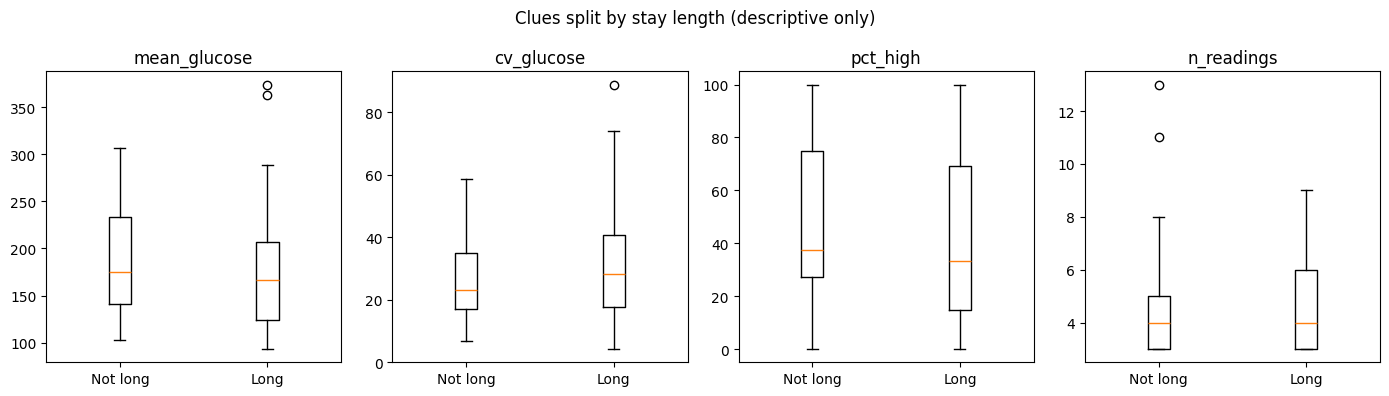

Median of each clue:
           mean_glucose  cv_glucose  pct_high  n_readings
long_stay                                                
0                 174.9        23.0      37.5         4.0
1                 166.2        28.1      33.3         4.0


In [11]:
clues_to_plot = ["mean_glucose", "cv_glucose", "pct_high", "n_readings"]

fig, axes = plt.subplots(1, len(clues_to_plot), figsize=(14, 4))
for ax, clue in zip(axes, clues_to_plot):
    not_long = cohort.loc[cohort["long_stay"] == 0, clue]
    long_ = cohort.loc[cohort["long_stay"] == 1, clue]
    ax.boxplot([not_long, long_])
    ax.set_xticklabels(["Not long", "Long"])
    ax.set_title(clue)
fig.suptitle("Clues split by stay length (descriptive only)")
plt.tight_layout()
plt.savefig("figures/clues_by_stay_length.png", dpi=150)
plt.show()

print("Median of each clue:")
print(cohort.groupby("long_stay")[clues_to_plot].median().round(1))

## Step 7. Machine learning: the practice-test method

### The danger: memorising
If a student sees the exact test questions while studying, a good score proves nothing. Models are the same. So we test them on stays they have **never seen**.

### Our small-data plan
We have very few stays, so a single split into training and testing would be unstable. Instead we use **cross-validation**:

1. Split patients into groups ("folds").
2. Train on some groups and test on patients held out from training.
3. Repeat across the grouped folds. Some folds may be excluded if they lack either outcome class.
4. Calculate AUROC only when a test fold contains both outcome classes. If this is not possible, the notebook reports that limitation rather than forcing a score.

Two safety rules:

- **Same patient stays together.** If one patient has two stays, both go in the same group, so the model never studies a patient and is then tested on that same patient.
- **All preparation happens inside the pipeline.** Filling gaps and rescaling numbers are *learned from the study part only*. This stops secret peeking.

### The three players
| Player | What it does |
|---|---|
| **Baseline (dummy)** | Ignores the clues and predicts the training-set proportion of long stays. Its AUROC is 0.5 when both classes occur in the test set. |
| **Logistic regression** | A simple, explainable model. It gives each clue a weight. |
| **Random forest** | Many small decision trees that vote. We keep the trees small so it does not just memorise. |

### The score: AUROC
- **0.5** = a coin flip (no skill)
- **1.0** = perfect
- Roughly, it answers: *"If I pick one long stay and one not-long stay at random, how often does the model give the long one the higher risk?"*

In [12]:
# Choose the clues (X), the answer (y), and the patient groups.
FEATURES = [
    "n_readings", "mean_glucose", "sd_glucose", "cv_glucose",
    "min_glucose", "max_glucose", "pct_low", "pct_high", "pct_in_range",
    "anchor_age", "is_female",
]
X = cohort[FEATURES]
y = cohort["long_stay"].astype(int)
groups = cohort["subject_id"]  # keep repeat admissions from one patient together
print("Admissions:", len(X), "| patients:", groups.nunique())
print("Long-stay outcomes:", y.value_counts().to_dict())


Admissions: 48 | patients: 27
Long-stay outcomes: {1: 27, 0: 21}


In [13]:
# A tiny demo dataset may not support fair model evaluation.
# Each test fold AND each training fold must have both outcome classes.
from sklearn.metrics import roc_auc_score


def make_pipeline(model):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

models = {
    "Baseline (class prevalence)": DummyClassifier(strategy="prior"),
    "Logistic regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random forest": RandomForestClassifier(n_estimators=100, min_samples_leaf=2,
                                             random_state=SEED, class_weight="balanced"),
}
all_scores = {}
results = None

if y.nunique() < 2 or groups.nunique() < 3:
    print("Not enough outcome classes or distinct patients for grouped evaluation.")
else:
    n_splits = min(5, groups.nunique())
    splits = list(GroupKFold(n_splits=n_splits).split(X, y, groups))
    valid_splits = [(train, test) for train, test in splits
                    if y.iloc[train].nunique() == 2 and y.iloc[test].nunique() == 2]
    print(f"Folds with both outcomes in training and testing: {len(valid_splits)} of {len(splits)}")
    if len(valid_splits) < 2:
        print("Too few valid patient-grouped folds. AUROC comparison skipped.")
    else:
        for name, model in models.items():
            fold_scores = []
            for train, test in valid_splits:
                pipeline = make_pipeline(model)
                pipeline.fit(X.iloc[train], y.iloc[train])
                probabilities = pipeline.predict_proba(X.iloc[test])[:, 1]
                fold_scores.append(roc_auc_score(y.iloc[test], probabilities))
            all_scores[name] = fold_scores
            print(f"{name}: mean AUROC {np.mean(fold_scores):.3f} "
                  f"(from {len(fold_scores)} exploratory folds)")
        results = all_scores

print("Note: this small demo cannot establish clinical prediction performance.")


Folds with both outcomes in training and testing: 5 of 5
Baseline (class prevalence): mean AUROC 0.500 (from 5 exploratory folds)
Logistic regression: mean AUROC 0.333 (from 5 exploratory folds)
Random forest: mean AUROC 0.572 (from 5 exploratory folds)
Note: this small demo cannot establish clinical prediction performance.


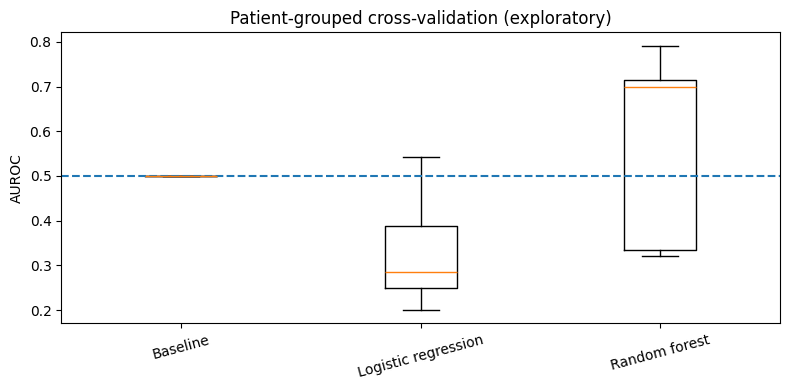

In [14]:
if all_scores:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot(list(all_scores.values()))
    ax.set_xticklabels([n.split(" (")[0] for n in all_scores], rotation=15)
    ax.axhline(0.5, linestyle="--")
    ax.set_ylabel("AUROC")
    ax.set_title("Patient-grouped cross-validation (exploratory)")
    plt.tight_layout()
    plt.savefig("figures/model_auroc_comparison.png", dpi=150)
    plt.show()
else:
    print("No AUROC plot produced because a reliable grouped comparison was not possible.")


### How to read your result (use your own numbers above)

- Is a model's **mean AUROC clearly above the baseline (0.5)**? If it is close to 0.5, say: *"this small evaluation did not demonstrate discrimination."* That is a valid result.
- Look at **lowest** and **highest**. With so few stays, the score can vary greatly between patient groups. A wide swing means: **do not trust a single number.**
- Even a good-looking score here would **not** show the model works in real hospitals. It would only be a reason to try again on a bigger dataset, and to check it on a completely separate set of patients.

## Step 8. Which clues did the simple model use?

This is for **explaining only**, not for scoring. We train logistic regression on **all** the stays, then look at its weights.

- A **positive** weight means a higher value of that clue pushed the guess toward "long stay".
- A **negative** weight means the opposite.
- Clues are on the same scale, so bar lengths can be compared.

With so few stays and clues that overlap (for example, mean glucose and max glucose move together), these weights are **unstable**. Treat them as hints, never proof.

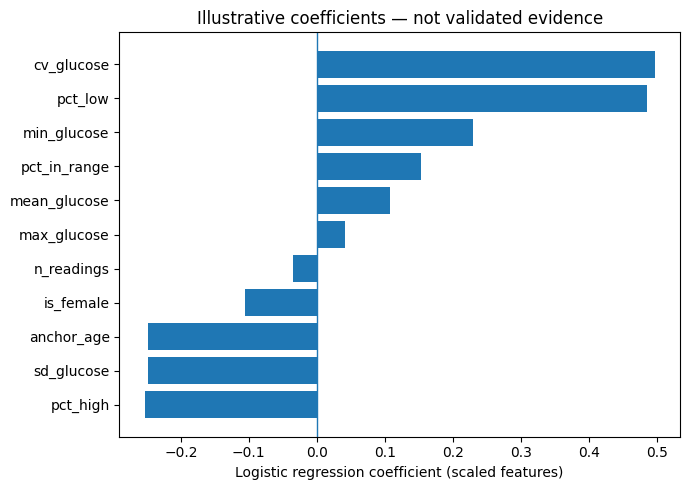

In [15]:
# Weights are illustrative, not evidence of clinical importance.
if results is not None and y.nunique() == 2:
    explain_model = make_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced")
    )
    explain_model.fit(X, y)
    weights = pd.Series(explain_model.named_steps["model"].coef_[0], index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(weights.index, weights.values)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Logistic regression coefficient (scaled features)")
    ax.set_title("Illustrative coefficients — not validated evidence")
    plt.tight_layout()
    plt.savefig("figures/logistic_regression_weights.png", dpi=150)
    plt.show()
else:
    print("Model weights skipped because evaluation was not possible.")


## Step 9. What we can and cannot say

### What this project shows
- How to define a diabetes cohort from diagnosis codes.
- How to clean lab data (missing values, units, impossible values).
- How to turn repeated measurements into one row per stay.
- How to avoid **leakage** by using only the first 48 hours.
- How to test a model fairly with patient-grouped cross-validation when outcome counts permit, and compare it to a baseline.

### What it does NOT show
- It does not show that glucose changes **cause** longer stays. Sicker patients can have both.
- It is not a validated prediction tool. It must never guide patient care.

### Limitations
- **Tiny data.** The demo has about 100 patients, so scores wobble and many details are unstable.
- **Lab glucose only.** Lab readings are checked now and then, not continuously. Bedside fingerstick tests are not included here.
- **More readings may mean a sicker patient.** `n_readings` is a clue, but it may simply show how unwell someone is.
- **Diagnosis codes** may miss people with diabetes, and they do not say how severe it is.
- **No treatment or illness-severity information** is used (insulin, other illnesses, intensive care).
- **No separate test set.** Cross-validation uses one small dataset only. A real study needs external validation.
- **Death is not modelled.** The demo has too few deaths for a fair model.
- The choices (48 hours, 3 readings, 7 days) are reasonable but arbitrary. Other choices could change the results.

### Next steps for a larger project
- Use the full MIMIC-IV (needs approved access), with many more patients.
- Add illness severity, medicines, other diagnoses and ICU data.
- Use time-aware glucose features, such as trends and time spent outside range.
- Use clinically defined outcomes such as complications, not just length of stay.
- Check the model on a different hospital or time period (external or temporal validation).